In [23]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score,precision_score, recall_score, classification_report, confusion_matrix, roc_auc_score, average_precision_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("battles_2025-12-18.csv", encoding="latin-1")
df

,attacker,defender,overtake,attacker_speed,defender_speed,speed_difference,lap_number,safety_car,yellow_flag,attacker_tyre_compound,...,defender_tyre_age,tyre_age_difference,track,sector,sector_type,is_in_drs_zone,drs_zone_length,track_type,attacker_qualification_rank,defender_qualification_rank
0,ALB,ALO,False,104.688,104.505,0.183,6,False,False,MEDIUM,...,6,0,AUSTIN,1,mixed,False,0,street,8,14
1,ALB,ALO,False,104.585,104.272,0.313,7,False,False,MEDIUM,...,7,0,AUSTIN,1,mixed,False,0,street,8,14
2,ALB,ALO,False,102.855,101.931,0.924,27,False,False,HARD,...,8,9,AUSTIN,1,mixed,False,0,street,15,19
3,ALB,ALO,False,103.718,103.174,0.544,34,False,False,HARD,...,12,4,AUSTIN,1,mixed,False,0,street,8,14
4,ALB,ALO,False,103.482,103.086,0.396,35,False,False,HARD,...,13,4,AUSTIN,1,mixed,False,0,street,8,14
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35163,ZHO,VET,False,94.988,94.812,0.176,18,False,False,WET,...,12,6,MONACO,1,technical,True,0,low-speed,20,9
35164,ZHO,VET,False,106.885,106.965,-0.080,53,False,False,HARD,...,34,30,MONTRÉAL,1,mixed,False,0,street,10,16
35165,ZHO,VET,False,133.502,134.159,-0.657,54,False,False,HARD,...,35,30,MONTRÉAL,1,mixed,False,0,street,10,16
35166,ZHO,VET,False,79.918,80.244,-0.326,55,False,False,HARD,...,36,30,MONTRÉAL,1,mixed,False,0,street,10,16


In [29]:
df.dtypes

,0
attacker,object
defender,object
overtake,bool
attacker_speed,float64
defender_speed,float64
speed_difference,float64
lap_number,int64
safety_car,bool
yellow_flag,bool
attacker_tyre_compound,object


In [4]:
TARGET = "overtake"

# Basic safety: ensure target is 0/1 int
df = df.copy()
df[TARGET] = df[TARGET].astype(int)

X = df.drop(columns=[TARGET])
y = df[TARGET]

In [5]:
# ----------------------------
# 1) Train / Val / Test split (70/15/15), stratified
# ----------------------------
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

print(f"Sizes --> train: {len(X_train)}, validation: {len(X_val)}, test: {len(X_test)}")
print("Overtake --> overall rate:", y.mean().round(4), "| train:", y_train.mean().round(4), "| val:", y_val.mean().round(4), "| test:", y_test.mean().round(4))

Sizes --> train: 24617, validation: 5275, test: 5276
Overtake --> overall rate: 0.0419 | train: 0.0418 | val: 0.0419 | test: 0.0419


In [6]:
# ----------------------------
# 2) Preprocessing: numeric scaling + categorical one-hot
# ----------------------------
categorical_cols = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
numeric_cols = [c for c in X.columns if c not in categorical_cols]

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
    ],
    remainder="drop"
)

In [7]:
# ----------------------------
# 3) Baseline models
# ----------------------------
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        class_weight="balanced",  # helpful if overtakes are rare
        random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=400,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )
}


In [8]:
def evaluate(model, X_eval, y_eval):
    pred = model.predict(X_eval)
    return {
        "accuracy": accuracy_score(y_eval, pred),
        "precision": precision_score(y_eval, pred, zero_division=0),
        "recall": recall_score(y_eval, pred, zero_division=0),
        "f1": f1_score(y_eval, pred)  # positive class is 1 (overtake=True)
    }

# ----------------------------
# 4) Train on train, evaluate on validation
# ----------------------------
results_val = {}
pipelines = {}

for name, clf in models.items():
    pipe = Pipeline(steps=[("prep", preprocess), ("clf", clf)])
    pipe.fit(X_train, y_train)
    pipelines[name] = pipe
    results_val[name] = evaluate(pipe, X_val, y_val)

print("\nValidation results:")
for name, m in results_val.items():
    print(f"{name:20s} --> Acc={m['accuracy']*100:.4}% | F1={m['f1']:.4f} | Precision: {m['precision']:.4f} | Recall: {m['recall']:.4f}")



Validation results:
Logistic Regression  --> Acc=71.03% | F1=0.1732 | Precision: 0.0983 | Recall: 0.7240
Random Forest        --> Acc=95.7% | F1=0.0000 | Precision: 0.0000 | Recall: 0.0000


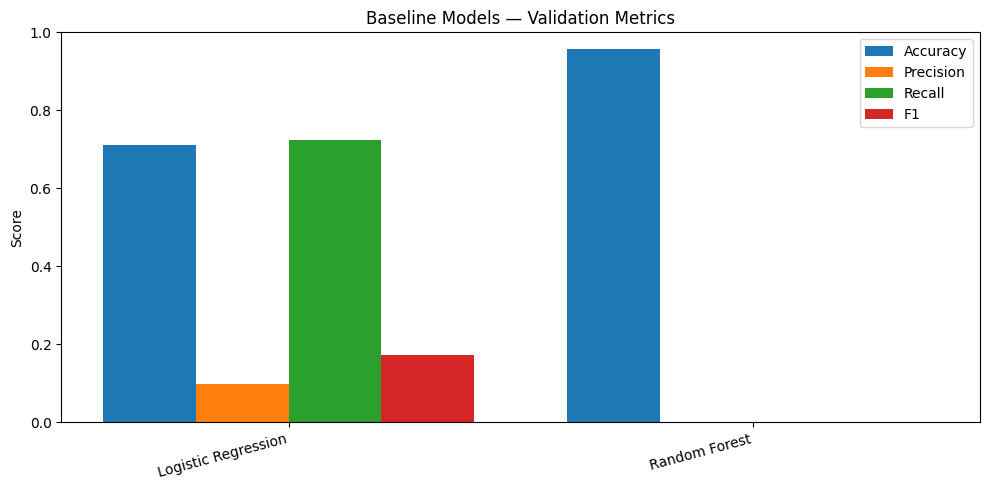

In [9]:
# ----------------------------
# 5) Plot validation metrics (Acc, Precision, Recall, F1)
# ----------------------------
names = list(results_val.keys())

accs  = [results_val[n]["accuracy"]  for n in names]
precs = [results_val[n]["precision"] for n in names]
recs  = [results_val[n]["recall"]    for n in names]
f1s   = [results_val[n]["f1"]        for n in names]

x = np.arange(len(names))
w = 0.20  # smaller width because we have 4 bars per group

plt.figure(figsize=(10, 5))
plt.bar(x - 1.5*w, accs,  width=w, label="Accuracy")
plt.bar(x - 0.5*w, precs, width=w, label="Precision")
plt.bar(x + 0.5*w, recs,  width=w, label="Recall")
plt.bar(x + 1.5*w, f1s,   width=w, label="F1")

plt.xticks(x, names, rotation=15, ha="right")
plt.ylim(0, 1)
plt.title("Baseline Models — Validation Metrics")
plt.ylabel("Score")
plt.legend()
plt.tight_layout()
plt.show()


In [10]:
# ----------------------------
# 6) Refit best model (by val F1) on train+val, evaluate once on test
# ----------------------------
best_name = max(results_val, key=lambda k: results_val[k]["f1"])
print("\nBest model by VAL F1:", best_name)

X_trainval = pd.concat([X_train, X_val], axis=0)
y_trainval = pd.concat([y_train, y_val], axis=0)

best_pipe = pipelines[best_name]
best_pipe.fit(X_trainval, y_trainval)

test_metrics = evaluate(best_pipe, X_test, y_test)
print("\nTest results (refit on train+val):")
print(f"Accuracy={test_metrics['accuracy']:.4f}  F1={test_metrics['f1']:.4f}")

y_test_pred = best_pipe.predict(X_test)
print("\nClassification report:\n", classification_report(y_test, y_test_pred, digits=4))
print("Confusion matrix:\n", confusion_matrix(y_test, y_test_pred))



Best model by VAL F1: Logistic Regression

Test results (refit on train+val):
Accuracy=0.7121  F1=0.1758

Classification report:
               precision    recall  f1-score   support

           0     0.9839    0.7112    0.8256      5055
           1     0.0999    0.7330    0.1758       221

    accuracy                         0.7121      5276
   macro avg     0.5419    0.7221    0.5007      5276
weighted avg     0.9468    0.7121    0.7984      5276

Confusion matrix:
 [[3595 1460]
 [  59  162]]


In [17]:
# ----------------------------
# 7) Models + hyperparameter grids
# ----------------------------
models_and_grids = {
    "Logistic Regression": (
        LogisticRegression(max_iter=2000, random_state=42),
        {
            "clf__C": [0.01, 0.1, 1, 3, 10],
            "clf__class_weight": ["balanced"],
            "clf__solver": ["lbfgs"],
            "clf__penalty": ["l2"],
        }
    ),
    "Random Forest": (
        RandomForestClassifier(random_state=42, n_jobs=-1),
        {
            "clf__n_estimators": [200, 400],
            "clf__max_depth": [None, 15],
            "clf__min_samples_leaf": [1, 5],
            "clf__max_features": ["sqrt"],
            "clf__class_weight": ["balanced_subsample"],
        }
    ),
}

In [18]:
def evaluate_with_threshold(model, X_eval, y_eval, threshold=0.5):
    """Evaluate using predict_proba + a probability threshold."""
    proba = model.predict_proba(X_eval)[:, 1]
    pred = (proba >= threshold).astype(int)

    return {
        "accuracy": accuracy_score(y_eval, pred),
        "precision": precision_score(y_eval, pred, zero_division=0),
        "recall": recall_score(y_eval, pred, zero_division=0),
        "f1": f1_score(y_eval, pred, zero_division=0),
    }

def best_threshold_by_f1(model, X_val, y_val):
    """Find threshold on validation set that maximizes F1."""
    proba = model.predict_proba(X_val)[:, 1]
    thresholds = np.linspace(0.01, 0.99, 99)

    best_thr = 0.5
    best_f1 = -1.0
    for t in thresholds:
        pred = (proba >= t).astype(int)
        f1 = f1_score(y_val, pred, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_thr = float(t)
    return best_thr, best_f1


In [19]:
# ----------------------------
# 8) Train on train (GridSearchCV), tune threshold on val, evaluate on val
# ----------------------------
results_val = {}
pipelines = {}
best_thresholds = {}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

for name, (base_clf, param_grid) in models_and_grids.items():
    base_pipe = Pipeline(steps=[("prep", preprocess), ("clf", base_clf)])

    gs = GridSearchCV(
        estimator=base_pipe,
        param_grid=param_grid,
        scoring="f1",          # tune hyperparams for F1
        cv=cv,
        n_jobs=-1,
        verbose=2
    )
    gs.fit(X_train, y_train)

    best_pipe = gs.best_estimator_
    pipelines[name] = best_pipe

    # Step 1: threshold tuning on validation
    best_thr, best_f1 = best_threshold_by_f1(best_pipe, X_val, y_val)
    best_thresholds[name] = best_thr

    # Evaluate on validation using tuned threshold
    results_val[name] = evaluate_with_threshold(best_pipe, X_val, y_val, threshold=best_thr)

    print(f"\n{name} best params: {gs.best_params_}")
    print(f"{name} best VAL threshold (max F1): {best_thr:.2f}")

print("\nValidation results (tuned hyperparams + tuned threshold):")
for name, m in results_val.items():
    print(
        f"{name:20s} --> "
        f"Acc={m['accuracy']*100:.2f}% | "
        f"F1={m['f1']:.4f} | "
        f"Precision={m['precision']:.4f} | "
        f"Recall={m['recall']:.4f} | "
        f"Thr={best_thresholds[name]:.2f}"
    )

Fitting 3 folds for each of 5 candidates, totalling 15 fits

Logistic Regression best params: {'clf__C': 1, 'clf__class_weight': 'balanced', 'clf__penalty': 'l2', 'clf__solver': 'lbfgs'}
Logistic Regression best VAL threshold (max F1): 0.68
Fitting 3 folds for each of 8 candidates, totalling 24 fits

Random Forest best params: {'clf__class_weight': 'balanced_subsample', 'clf__max_depth': 15, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 5, 'clf__n_estimators': 200}
Random Forest best VAL threshold (max F1): 0.57

Validation results (tuned hyperparams + tuned threshold):
Logistic Regression  --> Acc=86.43% | F1=0.2149 | Precision=0.1418 | Recall=0.4434 | Thr=0.68
Random Forest        --> Acc=92.17% | F1=0.2251 | Precision=0.1923 | Recall=0.2715 | Thr=0.57


In [20]:
# ----------------------------
# Evaluate improved models on TEST (use VAL-tuned thresholds)
# ----------------------------
test_thresholds = {
    "Logistic Regression": 0.68,
    "Random Forest": 0.57,
}

print("\nTest results (tuned hyperparams + VAL-tuned threshold):")
for name in ["Logistic Regression", "Random Forest"]:
    m = evaluate_with_threshold(pipelines[name], X_test, y_test, threshold=test_thresholds[name])
    print(
        f"{name:20s} --> "
        f"Acc={m['accuracy']*100:.2f}% | "
        f"F1={m['f1']:.4f} | "
        f"Precision={m['precision']:.4f} | "
        f"Recall={m['recall']:.4f} | "
        f"Thr={test_thresholds[name]:.2f}"
    )


Test results (tuned hyperparams + VAL-tuned threshold):
Logistic Regression  --> Acc=86.79% | F1=0.2195 | Precision=0.1458 | Recall=0.4434 | Thr=0.68
Random Forest        --> Acc=92.44% | F1=0.2400 | Precision=0.2072 | Recall=0.2851 | Thr=0.57


In [21]:
print("\nDetailed TEST reports:")
for name in ["Logistic Regression", "Random Forest"]:
    thr = test_thresholds[name]
    proba = pipelines[name].predict_proba(X_test)[:, 1]
    pred = (proba >= thr).astype(int)

    print(f"\n{name} (thr={thr:.2f})")
    print("Confusion matrix:\n", confusion_matrix(y_test, pred))
    print("Classification report:\n", classification_report(y_test, pred, digits=4))


Detailed TEST reports:

Logistic Regression (thr=0.68)
Confusion matrix:
 [[4481  574]
 [ 123   98]]
Classification report:
               precision    recall  f1-score   support

           0     0.9733    0.8864    0.9278      5055
           1     0.1458    0.4434    0.2195       221

    accuracy                         0.8679      5276
   macro avg     0.5596    0.6649    0.5737      5276
weighted avg     0.9386    0.8679    0.8982      5276


Random Forest (thr=0.57)
Confusion matrix:
 [[4814  241]
 [ 158   63]]
Classification report:
               precision    recall  f1-score   support

           0     0.9682    0.9523    0.9602      5055
           1     0.2072    0.2851    0.2400       221

    accuracy                         0.9244      5276
   macro avg     0.5877    0.6187    0.6001      5276
weighted avg     0.9363    0.9244    0.9300      5276



In [24]:
def precision_at_top_k_percent(y_true, y_proba, k=0.10):
    """Precision among the top k% highest predicted probabilities."""
    y_true = np.asarray(y_true)
    y_proba = np.asarray(y_proba)

    n = len(y_true)
    k_n = max(1, int(np.ceil(k * n)))
    idx = np.argsort(y_proba)[::-1][:k_n]
    return y_true[idx].mean()  # since y_true is 0/1

def metrics_at_threshold(y_true, proba, thr):
    pred = (proba >= thr).astype(int)
    return {
        "acc": accuracy_score(y_true, pred),
        "precision": precision_score(y_true, pred, zero_division=0),
        "recall": recall_score(y_true, pred, zero_division=0),
        "f1": f1_score(y_true, pred, zero_division=0),
        "pred": pred
    }

def interpret_model(pipe, top_n=20):
    """LR -> coefficients; RF -> feature importances. Works with your ColumnTransformer."""
    prep = pipe.named_steps["prep"]
    clf = pipe.named_steps["clf"]

    feature_names = prep.get_feature_names_out()

    if hasattr(clf, "coef_"):  # Logistic Regression
        coefs = clf.coef_.ravel()
        df_imp = pd.DataFrame({"feature": feature_names, "value": coefs})
        df_imp["abs"] = df_imp["value"].abs()
        df_imp = df_imp.sort_values("abs", ascending=False)

        print("\nTop positive (increase overtake probability):")
        print(df_imp.sort_values("value", ascending=False).head(top_n)[["feature", "value"]])

        print("\nTop negative (decrease overtake probability):")
        print(df_imp.sort_values("value", ascending=True).head(top_n)[["feature", "value"]])

    elif hasattr(clf, "feature_importances_"):  # Random Forest
        imps = clf.feature_importances_
        df_imp = pd.DataFrame({"feature": feature_names, "value": imps})
        df_imp = df_imp.sort_values("value", ascending=False)

        print(f"\nTop {top_n} feature importances (Random Forest):")
        print(df_imp.head(top_n))

    else:
        print("\nNo built-in coefficients/importances available for this model.")


def inspect_errors(pipe, X_eval, y_eval, thr, n_show=15):
    """Show false positives / false negatives, most informative first."""
    proba = pipe.predict_proba(X_eval)[:, 1]
    pred = (proba >= thr).astype(int)

    inspect_df = X_eval.copy()
    inspect_df["y_true"] = np.asarray(y_eval)
    inspect_df["proba"] = proba
    inspect_df["y_pred"] = pred

    false_pos = inspect_df[(inspect_df["y_true"] == 0) & (inspect_df["y_pred"] == 1)].sort_values("proba", ascending=False)
    false_neg = inspect_df[(inspect_df["y_true"] == 1) & (inspect_df["y_pred"] == 0)].sort_values("proba", ascending=True)

    print("\nFalse Positives (highest proba, most confident mistakes):")
    print(false_pos.head(n_show))

    print("\nFalse Negatives (lowest proba among true overtakes):")
    print(false_neg.head(n_show))


# ----------------------------
# EVALUATE BOTH MODELS
# ----------------------------
models_to_check = ["Logistic Regression", "Random Forest"]

# Use your validation-chosen thresholds (edit if yours differ)
best_thresholds = {
    "Logistic Regression": 0.68,
    "Random Forest": 0.57
}

for name in models_to_check:
    pipe = pipelines[name]
    thr = best_thresholds[name]

    print("\n" + "="*70)
    print(f"{name}  (threshold={thr:.2f})")

    # --- VALIDATION metrics (AUC + threshold metrics + Precision@10%)
    val_proba = pipe.predict_proba(X_val)[:, 1]
    val_auc = roc_auc_score(y_val, val_proba)
    val_prauc = average_precision_score(y_val, val_proba)
    val_p10 = precision_at_top_k_percent(y_val, val_proba, k=0.10)

    val_m = metrics_at_threshold(y_val, val_proba, thr)

    print("\n[VAL]")
    print(f"ROC-AUC:  {val_auc:.4f}")
    print(f"PR-AUC:   {val_prauc:.4f}")
    print(f"P@10%:    {val_p10:.4f}")
    print(f"Acc:      {val_m['acc']*100:.2f}%")
    print(f"Precision:{val_m['precision']:.4f} | Recall:{val_m['recall']:.4f} | F1:{val_m['f1']:.4f}")
    print("Confusion matrix:\n", confusion_matrix(y_val, val_m["pred"]))

    # --- TEST metrics (same threshold; do NOT retune)
    test_proba = pipe.predict_proba(X_test)[:, 1]
    test_auc = roc_auc_score(y_test, test_proba)
    test_prauc = average_precision_score(y_test, test_proba)
    test_p10 = precision_at_top_k_percent(y_test, test_proba, k=0.10)

    test_m = metrics_at_threshold(y_test, test_proba, thr)

    print("\n[TEST]")
    print(f"ROC-AUC:  {test_auc:.4f}")
    print(f"PR-AUC:   {test_prauc:.4f}")
    print(f"P@10%:    {test_p10:.4f}")
    print(f"Acc:      {test_m['acc']*100:.2f}%")
    print(f"Precision:{test_m['precision']:.4f} | Recall:{test_m['recall']:.4f} | F1:{test_m['f1']:.4f}")
    print("Confusion matrix:\n", confusion_matrix(y_test, test_m["pred"]))
    print("\nClassification report:\n", classification_report(y_test, test_m["pred"], digits=4))

    # --- Interpretability (coefficients for LR / importances for RF)
    print("\n[INTERPRETATION]")
    interpret_model(pipe, top_n=20)

    # --- Debug failures (inspect FP/FN on TEST)
    print("\n[DEBUG FAILURES ON TEST]")
    inspect_errors(pipe, X_test, y_test, thr, n_show=15)



Logistic Regression  (threshold=0.68)

[VAL]
ROC-AUC:  0.7825
PR-AUC:   0.1374
P@10%:    0.1477
Acc:      86.43%
Precision:0.1418 | Recall:0.4434 | F1:0.2149
Confusion matrix:
 [[4461  593]
 [ 123   98]]

[TEST]
ROC-AUC:  0.7749
PR-AUC:   0.1541
P@10%:    0.1496
Acc:      86.79%
Precision:0.1458 | Recall:0.4434 | F1:0.2195
Confusion matrix:
 [[4481  574]
 [ 123   98]]

Classification report:
               precision    recall  f1-score   support

           0     0.9733    0.8864    0.9278      5055
           1     0.1458    0.4434    0.2195       221

    accuracy                         0.8679      5276
   macro avg     0.5596    0.6649    0.5737      5276
weighted avg     0.9386    0.8679    0.8982      5276


[INTERPRETATION]

Top positive (increase overtake probability):
                                      feature     value
85            cat__defender_tyre_compound_WET  1.854016
50                          cat__defender_DOO  1.793334
55                          cat__defender_L


LR aggregated importance (correct mapping):
orig
defender                       15.707804
attacker                       14.341573
defender_tyre_compound          4.128867
track                           3.416233
attacker_tyre_compound          2.369283
defender_tyre_age               0.900563
speed_difference                0.677562
lap_number                      0.564263
attacker_tyre_age               0.548229
sector_type                     0.387019
track_type                      0.387019
is_in_drs_zone                  0.219890
defender_qualification_rank     0.184322
yellow_flag                     0.178803
safety_car                      0.178803
attacker_qualification_rank     0.131963
tyre_age_difference             0.045381
defender_speed                  0.034852
drs_zone_length                 0.029513
attacker_speed                  0.010481
sector                          0.000000

RF aggregated importance (correct mapping):
orig
speed_difference               0.216011

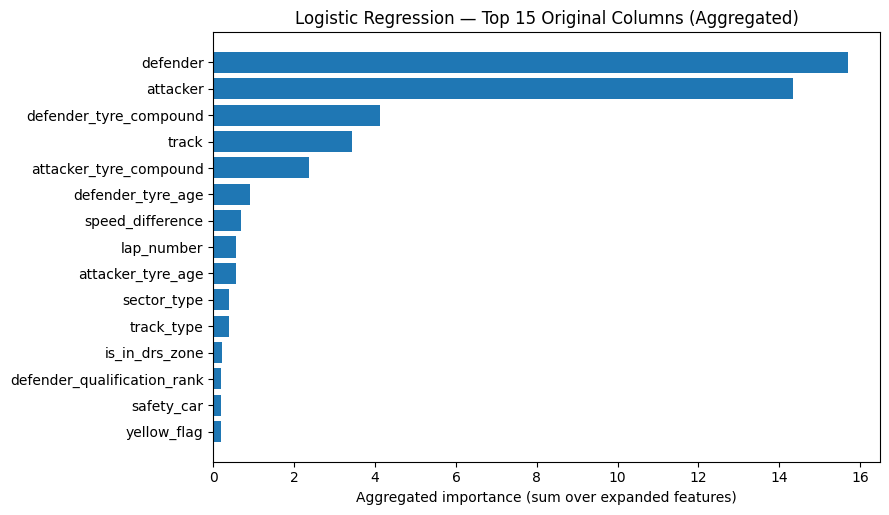

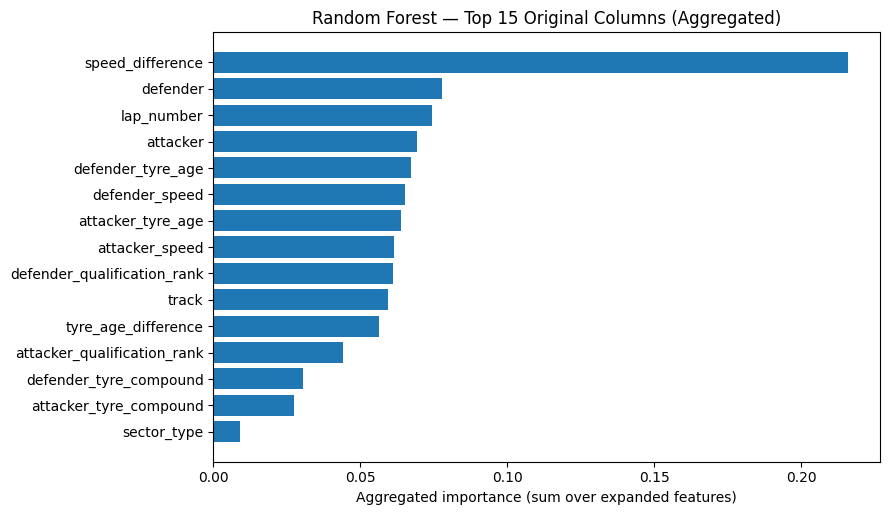


Top 25 expanded LR features:
cat__defender_tyre_compound_WET             1.854016
cat__defender_DOO                           1.793334
cat__attacker_DOO                           1.700819
cat__defender_BOR                           1.638215
cat__defender_HAD                           1.347563
cat__defender_LAT                           1.167930
cat__defender_tyre_compound_INTERMEDIATE    1.143945
cat__attacker_MSC                           1.125829
cat__attacker_VER                           0.923868
cat__attacker_BOR                           0.910538
num__defender_tyre_age                      0.900563
cat__attacker_tyre_compound_INTERMEDIATE    0.877593
cat__defender_VER                           0.866792
cat__attacker_PER                           0.740125
cat__defender_ANT                           0.713915
cat__attacker_tyre_compound_nan             0.711676
cat__attacker_SAI                           0.705259
cat__defender_SAI                           0.699724
cat__attacker_HA

In [37]:
categorical_cols = [
    'attacker', 'defender', 'safety_car', 'yellow_flag',
    'attacker_tyre_compound', 'defender_tyre_compound',
    'track', 'sector_type', 'is_in_drs_zone', 'track_type'
]

numeric_cols = [
    'attacker_speed', 'defender_speed', 'speed_difference', 'lap_number',
    'attacker_tyre_age', 'defender_tyre_age', 'tyre_age_difference',
    'sector', 'drs_zone_length', 'attacker_qualification_rank',
    'defender_qualification_rank'
]

ALL_ORIG = set(categorical_cols + numeric_cols)

def map_to_original(expanded_name: str) -> str:
    """
    Map expanded feature name back to original column.
    Works with ColumnTransformer get_feature_names_out() format:
      num__<col>
      cat__<col>_<category>
    Uses your known column lists to avoid underscore bugs.
    """
    if expanded_name.startswith("num__"):
        col = expanded_name[len("num__"):]
        return col if col in ALL_ORIG else col  # fallback

    if expanded_name.startswith("cat__"):
        rest = expanded_name[len("cat__"):]  # e.g. 'is_in_drs_zone_True' or 'track_MONACO'
        # find the longest categorical col that is a prefix of rest + "_"
        matches = [c for c in categorical_cols if rest == c or rest.startswith(c + "_")]
        if matches:
            # choose the longest match (handles underscores inside column names)
            return max(matches, key=len)
        return rest.split("_", 1)[0]  # fallback (should not happen now)

    # fallback
    return expanded_name

def get_expanded_importance(pipe, kind: str) -> pd.Series:
    """kind: 'lr' or 'rf' """
    prep = pipe.named_steps["prep"]
    clf = pipe.named_steps["clf"]
    feature_names = prep.get_feature_names_out()

    if kind == "lr":
        imp = np.abs(clf.coef_.ravel())
        return pd.Series(imp, index=feature_names).sort_values(ascending=False)
    elif kind == "rf":
        imp = clf.feature_importances_
        return pd.Series(imp, index=feature_names).sort_values(ascending=False)
    else:
        raise ValueError("kind must be 'lr' or 'rf'")

def aggregate_importance(expanded_series: pd.Series) -> pd.Series:
    orig = [map_to_original(n) for n in expanded_series.index]
    df = pd.DataFrame({"orig": orig, "imp": expanded_series.values})
    return df.groupby("orig")["imp"].sum().sort_values(ascending=False)

def plot_agg(agg: pd.Series, title: str):
    s = agg.sort_values(ascending=True)
    plt.figure(figsize=(9, max(5, len(s) * 0.35)))
    plt.barh(s.index, s.values)
    plt.title(title)
    plt.xlabel("Aggregated importance (sum over expanded features)")
    plt.tight_layout()
    plt.show()

# ----------------------------
# Run for both models
# ----------------------------
# Assumes these exist:
# pipelines["Logistic Regression"], pipelines["Random Forest"]

lr_exp = get_expanded_importance(pipelines["Logistic Regression"], kind="lr")
rf_exp = get_expanded_importance(pipelines["Random Forest"], kind="rf")

lr_agg = aggregate_importance(lr_exp)
rf_agg = aggregate_importance(rf_exp)

print("\nLR aggregated importance (correct mapping):")
print(lr_agg.to_string())

print("\nRF aggregated importance (correct mapping):")
print(rf_agg.to_string())

# Plot top 15 per model
plot_agg(lr_agg.head(15), "Logistic Regression — Top 15 Original Columns (Aggregated)")
plot_agg(rf_agg.head(15), "Random Forest — Top 15 Original Columns (Aggregated)")

# Optional: also print top expanded features
print("\nTop 25 expanded LR features:")
print(lr_exp.head(25).to_string())

print("\nTop 25 expanded RF features:")
print(rf_exp.head(25).to_string())
